In [74]:
import numpy as np
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

In [92]:
# input:
#     content_image p
#     style_image a
#     pretrained VGG network
#     content_layer = conv4_2
#     style_layers = [conv1_1, conv2_1, conv3_1, conv4_1, conv5_1]
#     alpha, beta
#     style_weights w_l
#     num_steps

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#importing content and style images
content_image = Image.open('baby-duck.jpg')
style_image = Image.open('picasso.jpg')

#resizing images to 256 by 256 pixels
raw_content_image = content_image.resize((256, 256), Image.Resampling.BICUBIC)
raw_style_image = style_image.resize((256, 256), Image.Resampling.BICUBIC)

to_tensor = transforms.ToTensor()
content_image = to_tensor(raw_content_image).unsqueeze(0)
style_image = to_tensor(raw_style_image).unsqueeze(0)

#importing pretrained vgg model
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features

for param in vgg.parameters():
    param.requires_grad = False

content_layer = '21'   # conv4_2

style_layers = ['0', '5', '10', '19', '28']   # conv1_1 ... conv5_1
selected_layers = [content_layer] + style_layers

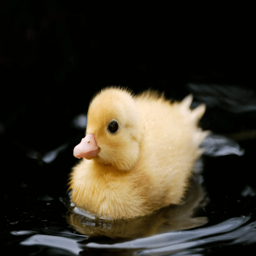

In [25]:
raw_content_image

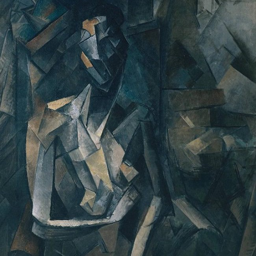

In [83]:
raw_style_image

In [84]:
def normalize_for_vgg(img):
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(1, 3, 1, 1)
    return (img - mean) / std

In [85]:
def gram_matrix(features):
    _, C, H, W = features.shape
    F = features.view(C, H * W)
    G = torch.mm(F, F.t())
    return G / (C * H * W)

In [86]:
def extract_features(image, model, selected_layers):
    features = {}
    x = image
    
    for name, layer in model._modules.items():
        x = layer(x)
        if name in selected_layers:
            features[name] = x
            
    return features

In [87]:
content_activations = extract_features(
    normalize_for_vgg(content_image), vgg, selected_layers
)

style_activations = extract_features(
    normalize_for_vgg(style_image), vgg, selected_layers
)

content_target = content_activations[content_layer].detach()

style_targets = {}
for l in style_layers:
    style_targets[l] = gram_matrix(style_activations[l]).detach()

In [88]:
#initialize image x we want to generate
x = content_image.clone().to(device)
x.requires_grad_(True)

tensor([[[[0.0078, 0.0157, 0.0157,  ..., 0.0039, 0.0039, 0.0039],
          [0.0157, 0.0196, 0.0196,  ..., 0.0039, 0.0039, 0.0039],
          [0.0235, 0.0235, 0.0157,  ..., 0.0039, 0.0039, 0.0039],
          ...,
          [0.0039, 0.0000, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
          [0.0157, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
          [0.0353, 0.0078, 0.0039,  ..., 0.0039, 0.0039, 0.0039]],

         [[0.0118, 0.0118, 0.0118,  ..., 0.0039, 0.0039, 0.0039],
          [0.0118, 0.0118, 0.0157,  ..., 0.0039, 0.0039, 0.0039],
          [0.0118, 0.0118, 0.0118,  ..., 0.0039, 0.0039, 0.0039],
          ...,
          [0.0039, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
          [0.0118, 0.0039, 0.0039,  ..., 0.0039, 0.0039, 0.0039],
          [0.0196, 0.0078, 0.0039,  ..., 0.0039, 0.0039, 0.0039]],

         [[0.0039, 0.0039, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
          [0.0039, 0.0039, 0.0078,  ..., 0.0000, 0.0000, 0.0000],
          [0.0078, 0.0078, 0.0039,  ..., 0

In [89]:
def get_input_optimizer(input_img):
    input_img.requires_grad_(True)
    optimizer = optim.LBFGS([input_img])
    return optimizer

In [93]:
alpha = 1
beta = 1e6

w_l = 1/5

num_steps = 300

optimizer = optim.LBFGS([x.requires_grad_()])

step = [0]

while step[0] < num_steps:

    def closure():
        optimizer.zero_grad()

        generated_activations = extract_features(
            normalize_for_vgg(x), vgg, selected_layers
        )

        #content loss
        F_content = generated_activations[content_layer]
        L_content = torch.mean((F_content - content_target) ** 2)

        #style loss
        L_style = 0
        for l in style_layers:
            F_style = generated_activations[l]

            G = gram_matrix(F_style)
            A = style_targets[l]

            E_layer = torch.mean((G - A)**2)
            L_style += w_l*E_layer

        L_total = alpha*L_content + beta*L_style

        L_total.backward()

        step[0] += 1

        if step[0] % 50 == 0:
            print(
                f"step {step[0]} | "
                f"content {L_content.item():.4f} | "
                f"style {L_style.item():.4f} | "
                f"total {L_total.item():.4f}"
            )

        return L_total

    optimizer.step(closure)

    with torch.no_grad():
        x.clamp_(0, 1)

step 50 | content 1.4270 | style 0.0000 | total 3.4708
step 100 | content 1.3249 | style 0.0000 | total 2.7615
step 150 | content 1.2686 | style 0.0000 | total 2.4599
step 200 | content 1.2196 | style 0.0000 | total 2.3179
step 250 | content 1.1964 | style 0.0000 | total 2.2505
step 300 | content 1.1806 | style 0.0000 | total 2.2072


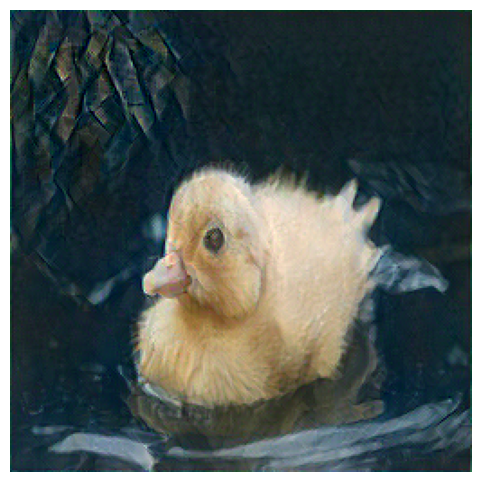

In [94]:
def tensor_to_image(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = image.clamp(0, 1)
    image = transforms.ToPILImage()(image)
    return image

result = tensor_to_image(x)

plt.figure(figsize=(6, 6))
plt.imshow(result)
plt.axis("off")
plt.show()

In [ ]:
result.save("output_phase1.png")